# Workforce Demand Forecasting Under Structural Change
**Participants:** Turki Alotaibi · Mohammed Albilaly  
**Programme:** Time Series Forecasting for AI Systems – SDAIA Academy  
**Cohort:** September 13–15, 2026

This reproducible study forecasts daily required headcount over a 10-day operational horizon and tests adaptation to the known **2025-04-01** structural change. All selection, features, scaling, and uncertainty calibration respect forecast origins.

In [1]:
# Colab-safe dependency setup: install only packages absent from the runtime.
import importlib.util, subprocess, sys
required = {'pandas':'pandas', 'numpy':'numpy', 'matplotlib':'matplotlib', 'seaborn':'seaborn',
            'statsmodels':'statsmodels', 'sklearn':'scikit-learn', 'lightgbm':'lightgbm'}
missing = [package for module, package in required.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *missing])
print('Dependencies ready:', ', '.join(required.values()))


Dependencies ready: pandas, numpy, matplotlib, seaborn, statsmodels, scikit-learn, lightgbm


In [2]:
import warnings, random, math, os, tempfile, urllib.request, importlib.util
from pathlib import Path
warnings.filterwarnings('ignore')
os.environ.setdefault('MPLCONFIGDIR',tempfile.mkdtemp(prefix='matplotlib_'))
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from lightgbm import LGBMRegressor

SEED=42; random.seed(SEED); np.random.seed(SEED)
sns.set_theme(style='whitegrid'); pd.set_option('display.max_rows', 100)
COURSE_RAW='https://raw.githubusercontent.com/MohammadYusif/time-series-forecasting-ai-systems/main'
DATA_URL=f'{COURSE_RAW}/data/workforce_demand.csv'
COURSE_UTIL_DIR=Path(tempfile.mkdtemp(prefix='sdaia_ts_course_'))

def load_course_module(module_name, relative_path):
 path=COURSE_UTIL_DIR/f'{module_name}.py'
 urllib.request.urlretrieve(f'{COURSE_RAW}/{relative_path}',path)
 spec=importlib.util.spec_from_file_location(f'course_{module_name}',path)
 module=importlib.util.module_from_spec(spec); spec.loader.exec_module(module)
 return module

course_metrics=load_course_module('metrics','common/metrics.py')
course_backtest=load_course_module('backtest','common/backtest.py')
required_metrics={'mae','rmse','mase','wape','coverage','interval_width'}
assert required_metrics.issubset(set(dir(course_metrics)))
assert hasattr(course_backtest,'seasonal_naive_forecast')
print('Official course utilities loaded into:',COURSE_UTIL_DIR)
print('Metric functions:',', '.join(sorted(required_metrics)))
print('Baseline function: seasonal_naive_forecast')

BREAK=pd.Timestamp('2025-04-01'); H=10; PERIOD=7


Official course utilities loaded into: C:\Users\USER\AppData\Local\Temp\sdaia_ts_course_ppowud9d
Metric functions: coverage, interval_width, mae, mase, rmse, wape
Baseline function: seasonal_naive_forecast


## 1. Data and diagnostics
The notebook downloads the authoritative CSV rather than embedding observations. Validation asserts the daily calendar, uniqueness, completeness, numeric finite target, and chronological order.

In [3]:
df=pd.read_csv(DATA_URL, parse_dates=['date']).sort_values('date').reset_index(drop=True)
assert list(df.columns)==['date','required_headcount']
assert not df['date'].duplicated().any() and not df.isna().any().any()
assert np.isfinite(df['required_headcount']).all()
assert (df['date'].diff().dropna()==pd.Timedelta(days=1)).all()
y=df.set_index('date')['required_headcount'].astype(float)
y.index.freq='D'
summary=pd.Series({'start':y.index.min().date(),'end':y.index.max().date(),'rows':len(y),
 'inferred_frequency':pd.infer_freq(y.index),'missing_values':int(df.isna().sum().sum()),
 'duplicate_dates':int(df.date.duplicated().sum())})
print(summary.to_string()); display(y.describe().to_frame('required_headcount').round(2))


start                 2024-01-01
end                   2025-12-31
rows                         731
inferred_frequency             D
missing_values                 0
duplicate_dates                0


,required_headcount
count,731.00
mean,70.34
std,25.37
min,25.00
25%,49.00
50%,71.00
75%,91.00
max,124.00


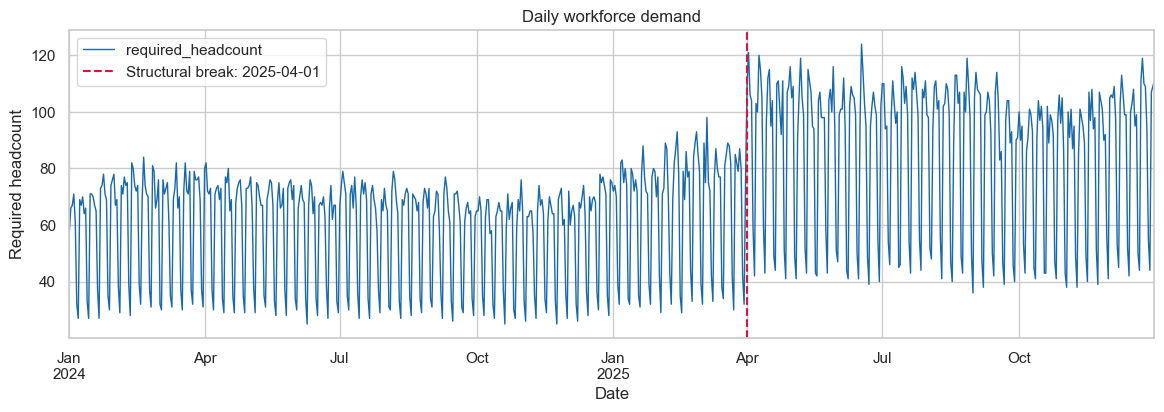

,count,mean,std,min,median,max
Post-break,275,86.57,26.51,36.0,99.0,124.0
Pre-break,456,60.56,18.82,25.0,68.0,98.0


,count,mean,std
day_type,,,
Weekday,523,83.38,16.57
Weekend,208,37.57,8.21


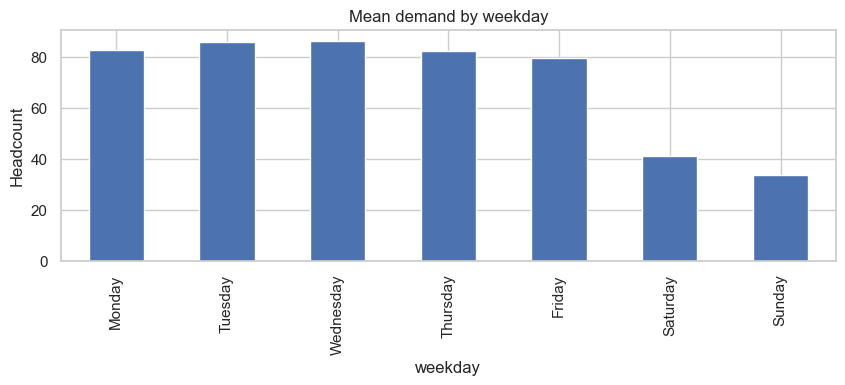

In [4]:
fig,ax=plt.subplots(figsize=(14,4)); y.plot(ax=ax,color='#1769aa',lw=1)
ax.axvline(BREAK,color='crimson',ls='--',label='Structural break: 2025-04-01')
ax.set(title='Daily workforce demand',ylabel='Required headcount',xlabel='Date'); ax.legend(); plt.show()
regime=pd.Series(np.where(y.index<BREAK,'Pre-break','Post-break'),index=y.index)
display(y.groupby(regime).agg(['count','mean','std','min','median','max']).round(2))
cal=pd.DataFrame({'demand':y,'day_type':np.where(y.index.dayofweek>=5,'Weekend','Weekday'),'weekday':y.index.day_name()})
display(cal.groupby('day_type').demand.agg(['count','mean','std']).round(2))
order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
cal.groupby('weekday').demand.mean().reindex(order).plot.bar(figsize=(10,3),title='Mean demand by weekday',ylabel='Headcount'); plt.show()


The level comparison quantifies the break, while weekday summaries expose operational weekly seasonality. A persistent level/trend shift argues against treating all old observations as equally relevant; the day-of-week contrast supports period 7.

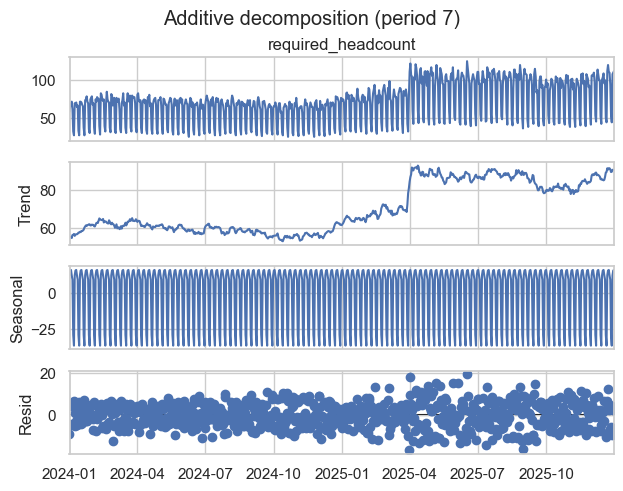

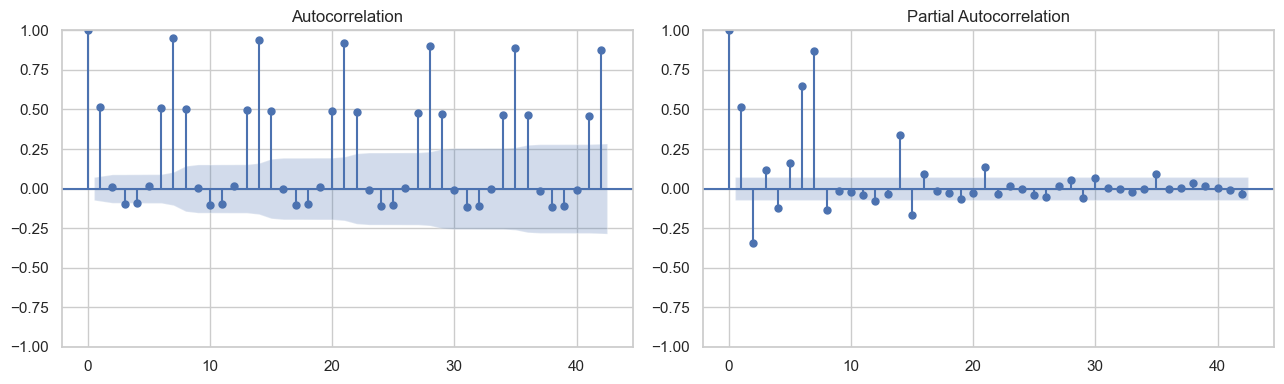

,series,statistic,p_value,lags,nobs
0,level,-0.5634,0.879,20,710
1,first difference,-8.2109,0.000,19,710


In [5]:
dec=seasonal_decompose(y,model='additive',period=7,extrapolate_trend='freq'); dec.plot(); plt.suptitle('Additive decomposition (period 7)',y=1.02); plt.show()
fig,axes=plt.subplots(1,2,figsize=(13,4)); plot_acf(y,lags=42,ax=axes[0]); plot_pacf(y,lags=42,ax=axes[1],method='ywm'); plt.tight_layout(); plt.show()
def adf_row(s,label):
 r=adfuller(s,autolag='AIC'); return {'series':label,'statistic':r[0],'p_value':r[1],'lags':r[2],'nobs':r[3]}
adf=pd.DataFrame([adf_row(y,'level'),adf_row(y.diff().dropna(),'first difference')])
display(adf.round(4))


**Diagnostic interpretation.** Decomposition separates the slowly changing level from the recurring seven-day pattern. ACF spikes at weekly lags confirm seasonal dependence; PACF indicates short-memory autoregressive structure. Because the level contains trend/a retrospective intervention and stationarity tests can be distorted by breaks, we use one regular difference (`d=1`) and one seasonal difference (`D=1`) as conservative SARIMA candidates, selected by training-only AIC. Differencing targets local changes while seasonal differencing removes weekly repetition; it does not magically remove break risk.

## 2–3. Models and leakage-safe features
The weekly seasonal naïve baseline calls the official course `common/backtest.py::seasonal_naive_forecast` downloaded to a temporary runtime directory. SARIMA chooses among a small, predeclared candidate set **inside each training fold**, never by test score. LightGBM uses lags 1,2,3,7,14,21,28; shifted rolling means/standard deviations over 7,14,28 days; calendar/cyclic weekly and annual information; and a deterministic time index. Recursive prediction appends its own predictions, so no test target can enter a later feature.


In [6]:
LAGS=[1,2,3,7,14,21,28]; WINDOWS=[7,14,28]
def score_forecast(actual,pred,train):
 assert isinstance(actual,pd.Series) and isinstance(train,pd.Series)
 assert len(train)>PERIOD and train.index.max()<actual.index.min() and len(train)<len(y)
 a=np.asarray(actual,float); p=np.asarray(pred,float); tr=np.asarray(train,float)
 assert len(a)==len(p) and np.isfinite(a).all() and np.isfinite(p).all() and np.isfinite(tr).all()
 return {'MAE':course_metrics.mae(a,p),'RMSE':course_metrics.rmse(a,p),
         'MASE':course_metrics.mase(a,p,tr,seasonal_period=PERIOD),
         'WAPE':course_metrics.wape(a,p)}
def feature_row(history,date,origin):
 h=np.asarray(history,float); doy=date.dayofyear
 d={f'lag_{k}':h[-k] for k in LAGS}
 for w in WINDOWS: d[f'roll_mean_{w}']=h[-w:].mean(); d[f'roll_std_{w}']=h[-w:].std(ddof=1)
 d.update({'dayofweek':date.dayofweek,'weekend':int(date.dayofweek>=5),'month':date.month,
  'dow_sin':np.sin(2*np.pi*date.dayofweek/7),'dow_cos':np.cos(2*np.pi*date.dayofweek/7),
  'doy_sin':np.sin(2*np.pi*doy/365.25),'doy_cos':np.cos(2*np.pi*doy/365.25),
  'time_idx':(date-origin).days})
 return d
def design(series):
 origin=df.date.min(); rows=[]
 vals=series.values
 for i in range(28,len(series)): rows.append({'date':series.index[i],'target':vals[i],**feature_row(vals[:i],series.index[i],origin)})
 return pd.DataFrame(rows).set_index('date')
def ml_forecast(train,dates):
 Xy=design(train); X=Xy.drop(columns='target'); target=Xy.target
 model=LGBMRegressor(n_estimators=250,learning_rate=.035,num_leaves=15,min_child_samples=20,
                    subsample=.9,colsample_bytree=.9,reg_lambda=.2,random_state=SEED,verbosity=-1,n_jobs=1)
 model.fit(X,target); history=train.tolist(); out=[]
 for date in dates:
  x=pd.DataFrame([feature_row(history,date,df.date.min())],index=[date])[X.columns]
  pred=max(0.,float(model.predict(x)[0])); out.append(pred); history.append(pred)
 return np.array(out),model
SARIMA_CANDIDATES=[((1,1,1),(1,1,0,7)),((2,1,0),(1,1,0,7)),((1,1,0),(0,1,1,7))]
def sarima_forecast(train,h):
 fits=[]
 for order,seasonal in SARIMA_CANDIDATES:
  try:
   fit=SARIMAX(train,order=order,seasonal_order=seasonal,trend='c',
    enforce_stationarity=False,enforce_invertibility=False).fit(disp=False,maxiter=150)
   if np.isfinite(fit.aic): fits.append((fit.aic,order,seasonal,fit))
  except Exception: pass
 if not fits: raise RuntimeError('Every predeclared SARIMA candidate failed on training data')
 _,order,seasonal,fit=min(fits,key=lambda z:z[0]); fc=fit.get_forecast(h)
 ci=np.asarray(fc.conf_int(alpha=.2)); return np.asarray(fc.predicted_mean),ci[:,0],ci[:,1],fit,order,seasonal


Training-AIC SARIMA selection: (1, 1, 1) (1, 1, 0, 7) AIC= 4521.42


,lb_stat,lb_pvalue
7,12.5565,0.0837
14,43.3129,0.0001


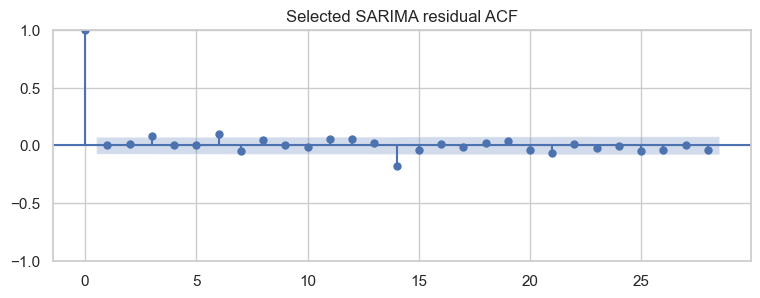

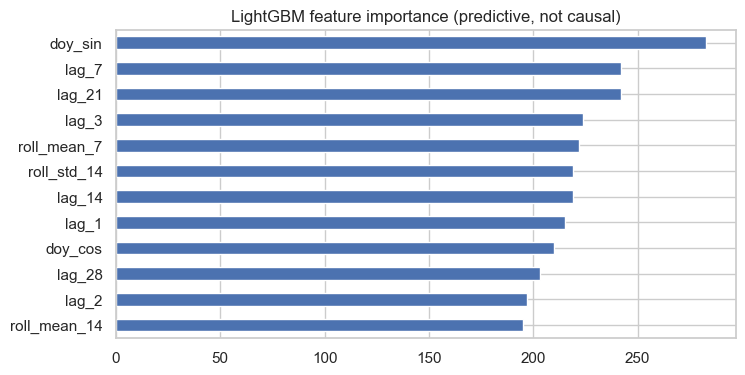

In [7]:
# Final-origin model illustrations and residual diagnostics; configuration uses training data only.
train_demo=y.iloc[:-H]; dates_demo=y.index[-H:]
sp,sl,su,sfit,sorder,sseasonal=sarima_forecast(train_demo,H)
mp,mlmodel=ml_forecast(train_demo,dates_demo)
print('Training-AIC SARIMA selection:',sorder,sseasonal,'AIC=',round(sfit.aic,2))
resid=sfit.resid.dropna(); display(acorr_ljungbox(resid,lags=[7,14],return_df=True).round(4))
fig,ax=plt.subplots(figsize=(9,3)); plot_acf(resid,lags=28,ax=ax); ax.set_title('Selected SARIMA residual ACF'); plt.show()
imp=pd.Series(mlmodel.feature_importances_,index=mlmodel.feature_name_).sort_values().tail(12)
imp.plot.barh(figsize=(8,4),title='LightGBM feature importance (predictive, not causal)'); plt.show()


Ljung–Box tests assess whether residual autocorrelation remains. Small p-values are reported honestly as evidence that the compact specification has not exhausted all signal; AIC selection is deliberately bounded to control repeated-fit cost and over-search. SARIMA's 80% Gaussian interval is native. Feature importance describes split utility for prediction—not an intervention effect or causal relationship.

## 4–6. Walk-forward evaluation and probabilistic forecasts
Twelve identical 10-day test windows deliberately span four pre-break origins, one window crossing 2025-04-01, and seven post-break origins. Each expanding fit starts on 2024-01-01; each rolling fit retains exactly 365 preceding days. Thus expanding is stable and retains long memory, whereas rolling discards stale observations and may adapt faster after the break. Both receive exactly the same test dates.

The official course backtest harness defines the required leakage-safe contract. Its standard split helpers place uniformly spaced folds at the series end, so this notebook keeps a justified explicit-origin equivalent to hold the deliberately selected break-centered test windows constant across strategies. The custom loop still fits afresh from training-only data, keeps every train/test boundary chronological and disjoint, and asserts identical test dates and actuals.


In [8]:
# Explicit origins make break coverage auditable while retaining >=365 observations.
origin_dates=pd.to_datetime(['2025-02-05','2025-02-25','2025-03-10','2025-03-22','2025-03-27',
 '2025-04-06','2025-05-06','2025-06-05','2025-07-05','2025-08-04','2025-09-03','2025-12-22'])
origins=[y.index.get_loc(d) for d in origin_dates]
def regime_for(test_dates):
 if test_dates.max()<BREAK:return 'Pre-break'
 if test_dates.min()<BREAK<=test_dates.max():return 'Crossing break'
 return 'Post-break'
records=[]; forecasts=[]; fold_windows=[]
for strategy in ['Expanding','Rolling']:
 for fold,end in enumerate(origins,1):
  start=0 if strategy=='Expanding' else end-365
  train=y.iloc[start:end]; test=y.iloc[end:end+H]
  assert len(train)>=365 and len(test)==H and train.index.max()<test.index.min()
  fold_windows.append({'strategy':strategy,'fold':fold,'train_start':train.index.min(),
                       'train_end':train.index.max(),'test_start':test.index.min(),'test_end':test.index.max()})
  preds={'Seasonal naive':course_backtest.seasonal_naive_forecast(train,H,PERIOD)}
  sar,slo,sup,fit,order,seas=sarima_forecast(train,H); preds['SARIMA']=sar
  ml,model=ml_forecast(train,test.index); preds['LightGBM']=ml
  reg=regime_for(test.index)
  for name,pred in preds.items():
   assert len(pred)==H and np.isfinite(pred).all()
   records.append({'strategy':strategy,'fold':fold,'origin':test.index.min().date(),'regime':reg,'model':name,**score_forecast(test,pred,train)})
   for dt,a,p in zip(test.index,test.values,pred): forecasts.append({'strategy':strategy,'fold':fold,'date':dt,'regime':reg,'model':name,'actual':a,'prediction':p})

results=pd.DataFrame(records); pred_df=pd.DataFrame(forecasts); fold_windows=pd.DataFrame(fold_windows)
assert results.shape[0]==2*12*3
exp_test=pred_df[(pred_df.strategy=='Expanding')&(pred_df.model=='Seasonal naive')][['fold','date','actual']].reset_index(drop=True)
roll_test=pred_df[(pred_df.strategy=='Rolling')&(pred_df.model=='Seasonal naive')][['fold','date','actual']].reset_index(drop=True)
assert exp_test.equals(roll_test)
assert fold_windows.groupby('fold').agg(test_starts=('test_start','nunique'),test_ends=('test_end','nunique')).eq(1).all().all()
print('Fold-level metrics (72 model/fold rows; official course metrics)'); display(results.round(3))
print('Audit: expanding and rolling strategies use identical 10-day test windows.')


Fold-level metrics (72 model/fold rows; official course metrics)


,strategy,fold,origin,regime,model,MAE,RMSE,MASE,WAPE
0,Expanding,1,2025-02-05,Pre-break,Seasonal naive,8.100,10.616,2.149,11.096
1,Expanding,1,2025-02-05,Pre-break,SARIMA,7.733,10.034,2.052,10.593
2,Expanding,1,2025-02-05,Pre-break,LightGBM,9.429,11.379,2.502,12.917
3,Expanding,2,2025-02-25,Pre-break,Seasonal naive,6.600,8.649,1.687,8.753
4,Expanding,2,2025-02-25,Pre-break,SARIMA,4.609,6.204,1.178,6.113
5,Expanding,2,2025-02-25,Pre-break,LightGBM,7.470,9.702,1.909,9.907
6,Expanding,3,2025-03-10,Pre-break,Seasonal naive,8.100,9.503,2.027,11.172
7,Expanding,3,2025-03-10,Pre-break,SARIMA,6.254,7.926,1.565,8.627
8,Expanding,3,2025-03-10,Pre-break,LightGBM,3.883,4.543,0.972,5.355
9,Expanding,4,2025-03-22,Pre-break,Seasonal naive,3.800,4.450,0.931,5.975


Audit: expanding and rolling strategies use identical 10-day test windows.


In [9]:
agg=results.groupby(['strategy','model'])[['MAE','RMSE','MASE','WAPE']].agg(['mean','std']).round(3)
print('Aggregated mean and fold-to-fold standard deviation'); display(agg)
regime_results=results.groupby(['strategy','regime','model'])[['MAE','RMSE','MASE','WAPE']].mean().round(3)
print('Mean performance by structural-break regime'); display(regime_results)


Aggregated mean and fold-to-fold standard deviation


MAE          RMSE          MASE          WAPE  \
                           mean    std   mean    std   mean    std   mean   
strategy  model                                                             
Expanding LightGBM        6.794  3.705  8.451  4.705  1.600  0.928  8.216   
          SARIMA          6.349  2.512  8.072  3.492  1.486  0.651  7.683   
          Seasonal naive  7.100  2.668  9.098  3.875  1.665  0.695  8.615   
Rolling   LightGBM        6.391  2.966  8.014  4.044  1.440  0.788  7.756   
          SARIMA          6.717  2.699  8.414  3.485  1.499  0.705  8.080   
          Seasonal naive  7.100  2.668  9.098  3.875  1.594  0.728  8.615   

                                 
                            std  
strategy  model                  
Expanding LightGBM        4.444  
          SARIMA          3.141  
          Seasonal naive  3.375  
Rolling   LightGBM        3.716  
          SARIMA          3.195  
          Seasonal naive  3.375

Mean performance by structural-break regime


MAE    RMSE   MASE    WAPE
strategy  regime         model                                        
Expanding Crossing break LightGBM        13.487  17.913  3.298  16.488
                         SARIMA          13.380  17.904  3.271  16.357
                         Seasonal naive  14.000  19.282  3.423  17.115
          Post-break     LightGBM         6.265   7.699  1.383   6.938
                         SARIMA           5.818   7.260  1.273   6.434
                         Seasonal naive   6.371   8.096  1.395   7.039
          Pre-break      LightGBM         6.047   7.403  1.554   8.384
                         SARIMA           5.519   7.034  1.412   7.701
                         Seasonal naive   6.650   8.304  1.699   9.249
Rolling   Crossing break LightGBM        13.576  18.057  3.324  16.597
                         SARIMA          13.120  17.460  3.213  16.040
                         Seasonal naive  14.000  19.282  3.428  17.115
          Post-break     LightGBM         5.661   7.116  1.143   6.266
                         SARIMA           6.514   7.901  1.320   7.194
                         Seasonal naive   6.371   8.096  1.283   7.039
          Pre-break      LightGBM         5.871   7.074  1.488   8.152
                         SARIMA           5.472   7.052  1.384   7.642
                         Seasonal naive   6.650   8.304  1.680   9.249

In [10]:
# Single authoritative sequential conformal implementation.
interval_rows=[]
for strategy in ['Expanding','Rolling']:
 prior=[]
 sub=pred_df[(pred_df.strategy==strategy)&(pred_df.model=='LightGBM')]
 for fold in range(1,13):
  z=sub[sub.fold==fold].sort_values('date')
  if prior:
   scores=np.concatenate(prior); rank=min(len(scores),math.ceil((len(scores)+1)*.80)); q=np.sort(scores)[rank-1]
   lo=np.maximum(0,z.prediction.values-q); hi=z.prediction.values+q
   assert np.isfinite([*lo,*hi]).all() and np.all(lo<=z.prediction.values) and np.all(z.prediction.values<=hi)
   for row,l,u in zip(z.itertuples(),lo,hi): interval_rows.append({'strategy':strategy,'fold':fold,'date':row.date,'regime':row.regime,'actual':row.actual,'prediction':row.prediction,'lower':l,'upper':u})
  prior.append(np.abs(z.actual.values-z.prediction.values)) # appended only after this fold's interval is evaluated
intervals=pd.DataFrame(interval_rows)
assert np.isfinite(intervals[['actual','prediction','lower','upper']]).all().all()
assert (intervals.lower<=intervals.prediction).all() and (intervals.prediction<=intervals.upper).all()

interval_summary_rows=[]
for (strategy,regime),z in intervals.groupby(['strategy','regime']):
 interval_summary_rows.append({'strategy':strategy,'regime':regime,'n':len(z),
  'coverage':course_metrics.coverage(z.actual,z.lower,z.upper),
  'mean_width':course_metrics.interval_width(z.lower,z.upper)})
interval_summary=pd.DataFrame(interval_summary_rows).set_index(['strategy','regime']).round(3)
overall_rows=[]
for strategy,z in intervals.groupby('strategy'):
 overall_rows.append({'strategy':strategy,'n':len(z),
  'coverage':course_metrics.coverage(z.actual,z.lower,z.upper),
  'mean_width':course_metrics.interval_width(z.lower,z.upper)})
overall=pd.DataFrame(overall_rows).set_index('strategy').round(3)
print('Sequential LightGBM conformal intervals — nominal coverage 80% (fold 1 calibration burn-in)')
display(overall); display(interval_summary)


Sequential LightGBM conformal intervals — nominal coverage 80% (fold 1 calibration burn-in)


,n,coverage,mean_width
strategy,,,
Expanding,110,0.882,26.183
Rolling,110,0.882,23.146


n  coverage  mean_width
strategy  regime                                  
Expanding Crossing break  10     0.500      18.298
          Post-break      70     0.914      26.457
          Pre-break       30     0.933      28.174
Rolling   Crossing break  10     0.500      16.880
          Post-break      70     0.900      22.355
          Pre-break       30     0.967      27.082

The finite-sample conformal rank is `ceil((n+1) × 0.80)` among **only earlier-fold** absolute errors (clipped to the largest available rank). The first fold is calibration burn-in and is not interval-scored. Nonnegative lower bounds are enforced and all interval ordering/alignment assertions pass. Coverage measures the share of actuals inside bounds; mean width measures sharpness. Wider bands tend to cover more but are less actionable. Exchangeability is strained at an abrupt break, so crossing-break undercoverage is plausible and must be monitored.

## 7. Result-driven operational selection

In [11]:
rank=results.groupby(['strategy','model']).agg(mean_MASE=('MASE','mean'),sd_MASE=('MASE','std'),mean_MAE=('MAE','mean')).sort_values(['mean_MASE','sd_MASE'])
display(rank.round(3))
champion_strategy,champion_model=rank.index[0]
challenger=rank.index[1]
print(f'Champion: {champion_strategy} {champion_model}')
print(f'Challenger: {challenger[0]} {challenger[1]}')
print('Fallback: Seasonal naive (period 7) under the champion window policy')
comparison=pd.DataFrame({
 'Seasonal naive':['Reference accuracy; highly stable','7 days','High','Conformal/empirical','Very low','Very low'],
 'SARIMA':['AIC-selected; inspect residuals','~1 year preferred','Medium-high','Native 80% + possible conformal','Medium-high','Medium'],
 'LightGBM':['Recursive; adapts nonlinear effects','>=28 days; 365 used','Medium','Sequential conformal 80%','Medium','Medium-high']},
 index=['Accuracy/adaptation','Required history','Interpretability','Interval support','Compute','Operational complexity'])
display(comparison)


mean_MASE  sd_MASE  mean_MAE
strategy  model                                       
Rolling   LightGBM            1.440    0.788     6.391
Expanding SARIMA              1.486    0.651     6.349
Rolling   SARIMA              1.499    0.705     6.717
          Seasonal naive      1.594    0.728     7.100
Expanding LightGBM            1.600    0.928     6.794
          Seasonal naive      1.665    0.695     7.100

Champion: Rolling LightGBM
Challenger: Expanding SARIMA
Fallback: Seasonal naive (period 7) under the champion window policy


,Seasonal naive,SARIMA,LightGBM
Accuracy/adaptation,Reference accuracy; highly stable,AIC-selected; inspect residuals,Recursive; adapts nonlinear effects
Required history,7 days,~1 year preferred,>=28 days; 365 used
Interpretability,High,Medium-high,Medium
Interval support,Conformal/empirical,Native 80% + possible conformal,Sequential conformal 80%
Compute,Very low,Medium-high,Medium
Operational complexity,Very low,Medium,Medium-high


The champion is selected mechanically from genuine mean fold MASE, with variability as tie-breaker—not predetermined. The runner-up is the challenger; weekly seasonal naïve remains the transparent fallback. Operational choice must also inspect post-break errors and interval calibration: a small average gain may not justify extra computation. Rolling windows favor adaptability; expanding windows favor stable estimation. The displayed result decides which trade-off won on these origins.

## 8. Limitations and audit
- The data are synthetic; operational behavior can be more irregular.
- The break is known retrospectively but may be unknown in production.
- Roughly two annual cycles limit annual-seasonality evidence.
- Conclusions apply to a 10-day horizon and these explicit origins.
- Forecast headcount is not a scheduling optimizer: skills, shifts, constraints, and costs remain downstream.
- Feature importance is predictive, not causal.
- Conformal guarantees rely on stability/exchangeability and can weaken under abrupt distribution shift.

**Execution audit:** The official course utilities are imported from a temporary runtime directory, leaving no repository artifact. Assertions verify daily/unique/complete data; identical test windows for expanding and rolling policies; chronological disjoint folds; training-only inputs passed to the official seasonal MASE function; recursive ML history initialized only from training and then extended only by predictions; finite aligned forecasts; and finite ordered intervals. All result tables above are computed during this run.
